In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pulp import *
from scipy.spatial.distance import cdist
from matplotlib.patches import Rectangle

In [2]:
print(listSolvers(onlyAvailable=True))
solver = GUROBI(msg=True)
print("Gurobi disponible:", solver.available())

['GUROBI', 'PULP_CBC_CMD']
Restricted license - for non-production use only - expires 2027-11-29
Gurobi disponible: True


{'m': 20, 'n': 10, 'dt': 10, 'K': 144, 'velocidad': 30, 'L': 30, 'r': {1: array([13.441469  , 16.95858604]), 2: array([22.5142954 , 11.18919528]), 3: array([25.40581003, 27.57176495]), 4: array([13.32406249, 26.66859773]), 5: array([ 4.41329693, 26.59807072]), 6: array([27.61359332,  1.32998312]), 7: array([13.63038519, 26.96594323]), 8: array([17.27038316, 21.05968426]), 9: array([6.54009468, 5.77331185]), 10: array([10.01039709,  6.16490311]), 11: array([ 8.10684548, 11.53060123]), 12: array([6.28672513, 7.44781853]), 13: array([27.3931048 ,  9.62398766]), 14: array([16.64410842, 18.10213325]), 15: array([27.42739048,  5.84425956]), 16: array([14.53393549, 18.06199623]), 17: array([14.19802746, 28.09420043]), 18: array([16.11922313, 27.90249465]), 19: array([5.81285286, 2.42971355]), 20: array([1.48186487, 4.29859502])}, 'delta': {(1, 1): np.float64(0.0), (1, 2): np.float64(3.0), (1, 3): np.float64(4.0), (1, 4): np.float64(2.0), (1, 5): np.float64(3.0), (1, 6): np.float64(5.0), (1, 7

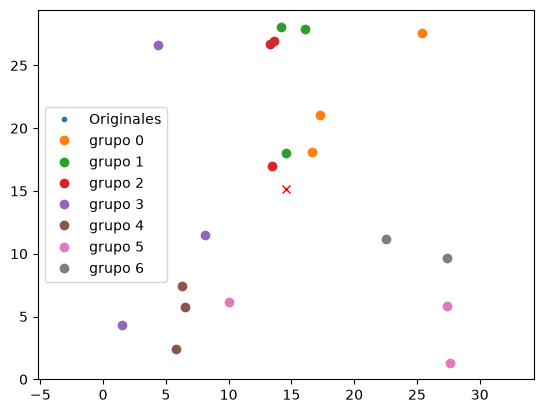

In [3]:
# Generación del escenario de usuarios
def escenario(m=20, #Número de usuarios
              n=10, #Número de médicos
              dt=10, #Intervalo de tiempo
              K=144,  #Número de intervalos de Tiempo
              velocidad=30, #Velocidad de los carros médicos en unidades de km/hora
              L=30 #Dimensión de la región aleatoria de usuarios
            ): 
    r=np.random.uniform(low=0, high=L, size=(m,2)) #Posiciones de los usuarios
    distancias = cdist(r, r)
    #Ya calculada la distancia, convertimos a r en un diccionario
    r={(i+1):r[i] for i in range(len(r))}
    delta=distancias/velocidad*60 #Matriz de distancias en minutos
    delta=np.ceil(delta/dt) #Matriz de distancias en intervalos de tiempo
    delta={(i+1,j+1):delta[i,j] for i in range(0,m) for j in range(0,m)}
    #Generación de parámetros de servicio de los pacientes
    a={i:np.random.randint(low=1, high=K-10) for i in range(1,m+1)} #Tiempo de llegada de los usuarios
    b={}
    c={}
    for i in range(1,m+1):
        ventana=np.random.randint(low=4, high=20) #Duración de la ventana de servicio
        ventana=min(144-a[i]-1, ventana)
        b[i]=a[i]+ventana+1
        duracion=np.random.randint(low=1, high=b[i]-a[i])
        c[i]=duracion

    #Parámetros auxiliares para construir las ecuaciones
    alfa={}
    tau={i:[] for i in range(1,m+1)}
    for i in range(1,m+1):
        for k in range(1, K+1):
            if(k>=a[i] and k<=b[i]-c[i]+1):
                alfa[i,k]=1
                tau[i].append(k)
            else:
                alfa[i,k]=0
    return {'m':m, 'n':n, 'dt':dt, 'K':K, 'velocidad':velocidad, 'L':L, 'r':r, 'delta':delta, 'a':a, 'b':b, 'c':c, 'tau':tau, 'alfa':alfa }
S=escenario()
print(S)
def partir_escenario_posicion(S, n):
    #Vamos a partir los escenarios de acuerdo con el número de puntos que tengamos. Vamos a suponer por ahora que n va entre 1 y 4, separando por medio de rectas horizontales y verticales
    if(n==1):
        return [S]
    if(n>1):
        ri=np.array(list(S['r'].values()))
        c=np.mean(ri, axis=0)
        print('c=',c)
        plt.plot(c[0], c[1], 'xr')
        ni=len(S['r'])/n-1 #Número de elementos por grupo
        if(int(ni)==ni):
            ni=ni-1
        else:
            ni=int(ni)+1
        print('Ni: ',ni)
        grupos=[]
        tmp=[]
        usados=[]
        for th in np.linspace(0,2*np.pi,360):
            u=np.array([np.cos(th), np.sin(th)])
            #plt.plot([c[0], c[0]+u[0]*10], [c[1], c[1]+u[1]*10], '-g')
            for k,v in S['r'].items():
                ang=np.arccos(np.dot(v-c,u)/np.linalg.norm(v-c))
                #fi= np.mod(np.arctan2((v-c)[1], (v-c)[0]), 2*np.pi)
                #dif=np.rad2deg(np.abs(th-fi))
                if(ang<np.deg2rad(1.0) and ang>=0 and k not in usados):# and dif<5):
                    #print(f'Indice usuario: {k}, posición {v}, ángulo de búsqueda: {np.rad2deg(th)}, \nAngulo de diferencia: {np.rad2deg(ang)}, Diferencia absoluta: {dif}, Unitario: {u}\n')
                    tmp.append(k)
                    usados.append(k)
                if(len(tmp)>ni):
                    grupos.append(tmp)
                    #for ind in tmp: 
                    #    plt.plot(S['r'][ind][0],S['r'][ind][1],'ob')
                    #    plt.text(S['r'][ind][0],S['r'][ind][1], str(ind)+','+str(len(grupos)))
                    tmp=[]
                    #print(np.rad2deg(th), [gi for gi in grupos])
        if(len(tmp)>0):
            grupos.append(tmp)
        plt.axis('equal')
        plt.grid()
        print(grupos)
    #Para cada grupo se requiere organizar la siguiente información: 
    #'m':m, 'n':n, 'dt':dt, 'K':K, 'velocidad':velocidad, 'L':L, 'r':r, 'delta':delta, 'a':a, 'b':b, 'c':c, 'tau':tau 
    Sout=[]
    for gr in grupos:
        tmp={'m':len(gr), 'n':S['n'], 'dt':S['dt'], 'K':S['K'], 'velocidad':S['velocidad'], 'L':S['L'], 
                'r':[], 'delta':{}, 'a':{}, 'b':{}, 'c':{}, 'tau':{} }
        tmp['r']={ind:S['r'][ind] for ind in gr}
        tmp['delta']={(i,j):S['delta'][i,j] for i in gr for j in gr}
        tmp['a']={ind:S['a'][ind] for ind in gr}
        tmp['b']={ind:S['b'][ind] for ind in gr}
        tmp['c']={ind:S['c'][ind] for ind in gr}
        tmp['alfa']={k:v for k,v in S['alfa'].items() if k[0] in gr}
        tmp['tau']={ind:S['tau'][ind] for ind in gr}
                        
        Sout.append(tmp)
    return Sout                        
ri=np.array(list(S['r'].values()))
plt.plot(ri[:,0], ri[:,1], '.', label='Originales')

S2=partir_escenario_posicion(S, n=7)    
for i,si in enumerate(S2):
    ri=np.array(list(si['r'].values()))
    plt.plot(ri[:,0], ri[:,1], 'o', label='grupo '+str(i))
plt.axis('equal')
plt.grid()
plt.legend()


In [4]:
def problemaLP(S):
    m=S['m']
    n=S['n']
    K=S['K']
    delta=S['delta']
    a=S['a']
    b=S['b']
    c=S['c']
    tau=S['tau']
    alfa=S['alfa']
    r=S['r']
    print('Construyendo problema')
    prob=LpProblem('Optimizacion_turnos', LpMinimize) #Dado que importamos toda la librería de Pulp
    #Construccion de variables
    #Uso de médicos:
    y={j:LpVariable('Doctor_'+str(j), cat=LpBinary) for j in range(1,n+1)}
    x={}
    for i in r.keys():
        for j in range(1, n+1):
            for k in range(1,K+1):
                if(alfa[i,k]==1): 
                    x[i,j,k]=LpVariable(f'Us{i}_Dr{j}_Time{k}', cat=LpBinary)

    #Función objetivo
    prob+=lpSum([y[j] for j in range(1,n+1)]), 'Función objetivo'

    #Restricción de que alguien tiene que atender al usuario, pero solo un doctor
    for i in r.keys():
        suma=0
        for j in range(1,n+1):
            for k in tau[i]:
                suma+=x[i,j,k]
        prob+=suma==1, 'Atención del usuario '+str(i)

    #Restricciones de tiempo entre atención y desplazamiento
    M=1000
    for i in r.keys():
        for j in range(1,n+1):
            for k in tau[i]:
                suma=0
                for eta in [i2 for i2 in r.keys() if i2!=i]:
                    for s in range(int(k-c[eta]-delta[eta,i]+1),k+1):
                        if((eta,j,s) in x.keys()):
                            suma+=x[eta,j,s]
                prob+=x[i,j,k]<=1-1/M*suma

    #Restricción 3, el médico puede atender si está activo
    for j in range(1,n+1):
        suma=0
        for i in r.keys():
            for k in tau[i]:
                suma+=x[i,j,k]
        prob+=suma<=M*y[j], f'El Doctor {j} atiende si está activo'
    print('Problema construido, solucionando')
    solver = GUROBI(
        msg=True,
        timeLimit=400,
        gapRel=0.001
    )
    prob.solve()
    return prob.objective.value()
#problemaLP(S)

Procediendo con 1 particiones
Construyendo problema
Problema construido, solucionando
Procediendo con 2 particiones
c= [14.07330452  9.68586867]
Ni:  8.0
[[10, 18, 13, 16, 6, 15, 19, 20, 12], [9, 17, 5, 14, 7, 8, 2, 4, 3], [11, 1]]
Construyendo problema
Problema construido, solucionando
Construyendo problema
Problema construido, solucionando
Construyendo problema
Problema construido, solucionando
Procediendo con 3 particiones
c= [14.07330452  9.68586867]
Ni:  6
[[10, 18, 13, 16, 6, 15, 19], [20, 12, 9, 17, 5, 14, 7], [8, 2, 4, 3, 11, 1]]
Construyendo problema
Problema construido, solucionando
Construyendo problema
Problema construido, solucionando
Construyendo problema
Problema construido, solucionando
Procediendo con 4 particiones
c= [14.07330452  9.68586867]
Ni:  3.0
[[10, 18, 13, 16], [6, 15, 19, 20], [12, 9, 17, 5], [14, 7, 8, 2], [4, 3, 11, 1]]
Construyendo problema
Problema construido, solucionando
Construyendo problema
Problema construido, solucionando
Construyendo problema
Prob

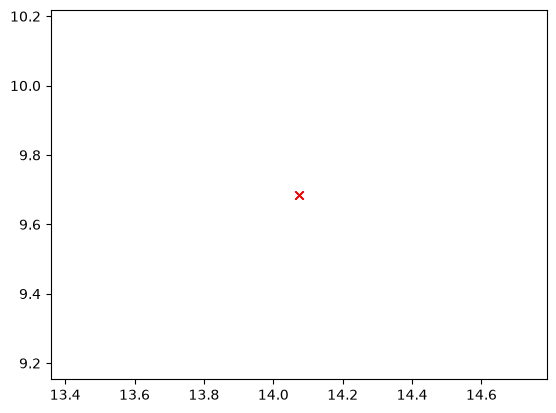

In [5]:
S=escenario()
L=[]
N=[]
for i in [1,2,3,4,5]:
    print('Procediendo con '+str(i)+' particiones')
    scen=partir_escenario_posicion(S, i)
    ni=[problemaLP(si) for si in scen]
    L.append(i)
    N.append(np.sum(ni))

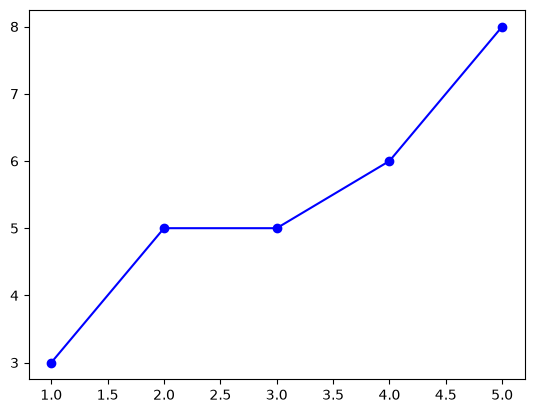

In [6]:
plt.plot(L,N,'o-b')